First Notebook to understnad the data and make inferences about the data. 
<br>
This notebook would also be used to check and confirm the transformations requried - to be done in DBT

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Reading the dataset  : 

In [8]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\vinay\Desktop\github\search_ads_growth_analytics_platform")
csv_path = PROJECT_ROOT / "data" / "raw" / "dataset.csv"

df = pd.read_csv(csv_path , nrows=20000)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [11]:
SAMPLE_FRAC = 0.01
CHUNK_SIZE = 500_000
RANDOM_SEED = 42

sample_chunks = []

for chunk in pd.read_csv(csv_path, chunksize=CHUNK_SIZE):
    sampled_chunk = chunk.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
    sample_chunks.append(sampled_chunk)

df_sample = pd.concat(sample_chunks, ignore_index=True)

print("Random sample shape:", df_sample.shape)
df_sample.head()

Random sample shape: (424488, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 04:32:52 UTC,view,12719453,2053013553559896355,NaN,matador,397.44,517886245,7d1528ae-8dfa-4c97-ab4c-974815b9f431
1,2019-10-01 06:06:39 UTC,view,10900328,2053013555069845885,appliances.kitchen.mixer,dauscher,12.84,519282157,55efefd9-53c4-472c-bf6e-45b60ea9ec5a
2,2019-10-01 05:11:34 UTC,view,3100564,2053013555262783879,appliances.kitchen.blender,philips,61.75,539168115,697beb54-e90e-4eeb-8822-eab39935c911
3,2019-10-01 05:04:16 UTC,view,26100001,2053013553887052089,NaN,sulu,25.74,555239099,19041a8f-8a4c-4d6f-934b-3130f33017fe
4,2019-10-01 09:04:19 UTC,view,1306569,2053013558920217191,computers.notebook,acer,1055.11,517726252,1872ffce-39dd-43de-ba53-a49b90281fed


In [12]:
print("Sample shape:", df_sample.shape)
print("\nColumns:")
print(df_sample.columns.tolist())

Sample shape: (424488, 9)

Columns:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


In [13]:
df_sample.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424488 entries, 0 to 424487
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     424488 non-null  object 
 1   event_type     424488 non-null  object 
 2   product_id     424488 non-null  int64  
 3   category_id    424488 non-null  int64  
 4   category_code  289458 non-null  object 
 5   brand          363592 non-null  object 
 6   price          424488 non-null  float64
 7   user_id        424488 non-null  int64  
 8   user_session   424488 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 29.1+ MB


In [14]:
missing_counts = df_sample.isna().sum().sort_values(ascending=False)
missing_pct = (df_sample.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct.round(2)
})

missing_summary

,missing_count,missing_pct
category_code,135030,31.81
brand,60896,14.35
event_time,0,0.00
product_id,0,0.00
event_type,0,0.00
category_id,0,0.00
price,0,0.00
user_id,0,0.00
user_session,0,0.00


In [15]:
event_type_counts = df_sample["event_type"].value_counts().reset_index()
event_type_counts.columns = ["event_type", "event_count"]

event_type_counts["event_pct"] = (
    event_type_counts["event_count"] 
    / event_type_counts["event_count"].sum() 
    * 100
).round(2)

event_type_counts

,event_type,event_count,event_pct
0,view,407931,96.10
1,cart,9184,2.16
2,purchase,7373,1.74


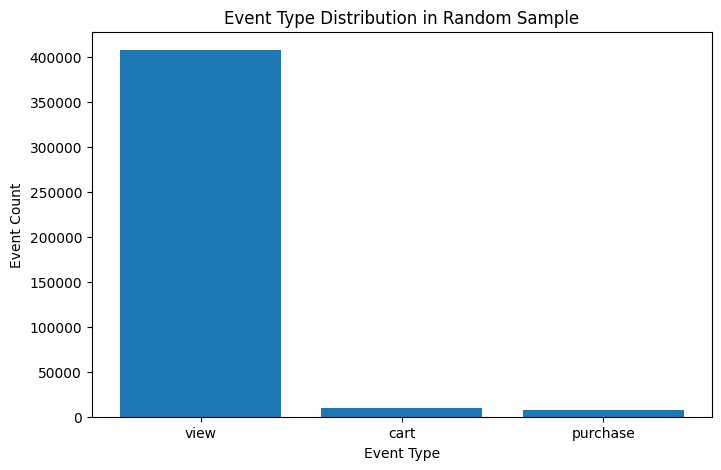

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(event_type_counts["event_type"], event_type_counts["event_count"])
plt.title("Event Type Distribution in Random Sample")
plt.xlabel("Event Type")
plt.ylabel("Event Count")
plt.show()

Time Stamp Marking : 

In [20]:
df_sample["event_time_parsed"] = pd.to_datetime(
    df_sample["event_time"],
    utc=True,
    errors="coerce"
)

timestamp_summary = pd.DataFrame({
    "metric": [
        "invalid_timestamps",
        "min_event_time",
        "max_event_time"
    ],
    "value": [
        df_sample["event_time_parsed"].isna().sum(),
        df_sample["event_time_parsed"].min(),
        df_sample["event_time_parsed"].max()
    ]
})

timestamp_summary

,metric,value
0,invalid_timestamps,0
1,min_event_time,2019-10-01 00:01:15+00:00
2,max_event_time,2019-10-31 23:59:42+00:00


In [21]:
df_sample["event_date"] = df_sample["event_time_parsed"].dt.date

daily_sample_activity = (
    df_sample
    .groupby("event_date")
    .agg(
        total_events=("event_type", "count"),
        active_users=("user_id", "nunique"),
        sessions=("user_session", "nunique")
    )
    .reset_index()
)

daily_sample_activity.head()

,event_date,total_events,active_users,sessions
0,2019-10-01,12414,11316,11702
1,2019-10-02,11931,10804,11198
2,2019-10-03,11253,10205,10560
3,2019-10-04,14201,12834,13362
4,2019-10-05,13290,12013,12499


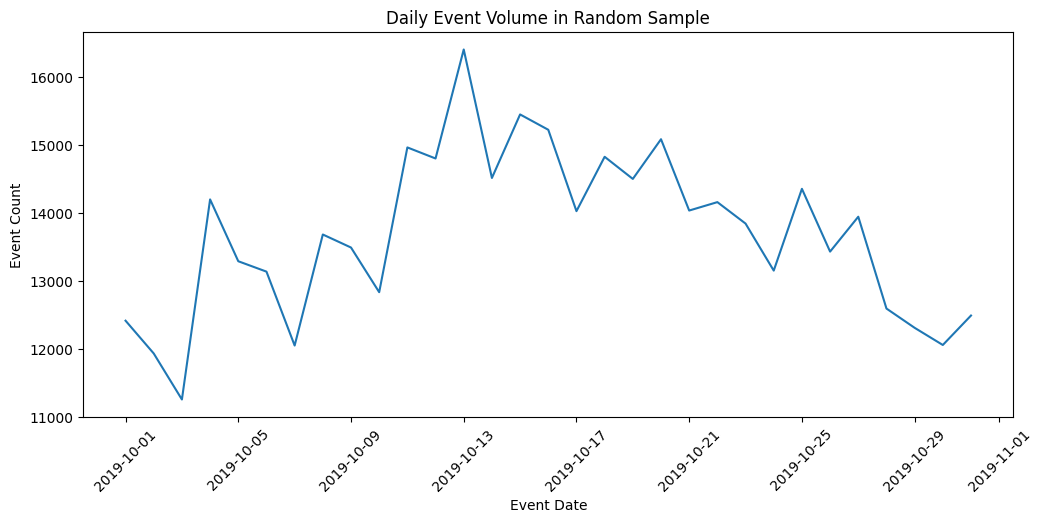

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sample_activity["event_date"], daily_sample_activity["total_events"])
plt.title("Daily Event Volume in Random Sample")
plt.xlabel("Event Date")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.show()

In [23]:
cardinality_summary = pd.DataFrame({
    "metric": [
        "unique_users",
        "unique_sessions",
        "unique_products",
        "unique_categories",
        "unique_category_codes",
        "unique_brands"
    ],
    "value": [
        df_sample["user_id"].nunique(),
        df_sample["user_session"].nunique(),
        df_sample["product_id"].nunique(),
        df_sample["category_id"].nunique(),
        df_sample["category_code"].nunique(dropna=True),
        df_sample["brand"].nunique(dropna=True)
    ]
})

cardinality_summary

,metric,value
0,unique_users,320788
1,unique_sessions,399070
2,unique_products,59527
3,unique_categories,597
4,unique_category_codes,126
5,unique_brands,2440


In [24]:
metadata_quality = pd.DataFrame({
    "field": ["category_code", "brand"],
    "missing_count": [
        df_sample["category_code"].isna().sum(),
        df_sample["brand"].isna().sum()
    ],
    "missing_pct": [
        round(df_sample["category_code"].isna().mean() * 100, 2),
        round(df_sample["brand"].isna().mean() * 100, 2)
    ],
    "unique_non_null_values": [
        df_sample["category_code"].nunique(dropna=True),
        df_sample["brand"].nunique(dropna=True)
    ]
})

metadata_quality

,field,missing_count,missing_pct,unique_non_null_values
0,category_code,135030,31.81,126
1,brand,60896,14.35,2440


In [25]:
top_categories = (
    df_sample["category_code"]
    .fillna("unknown")
    .value_counts()
    .head(15)
    .reset_index()
)

top_categories.columns = ["category_code", "event_count"]
top_categories

,category_code,event_count
0,unknown,135030
1,electronics.smartphone,115296
2,electronics.clocks,13247
3,computers.notebook,11559
4,electronics.video.tv,11044
5,electronics.audio.headphone,10929
6,appliances.kitchen.refrigerators,8817
7,appliances.kitchen.washer,8741
8,appliances.environment.vacuum,7970
9,apparel.shoes,7675


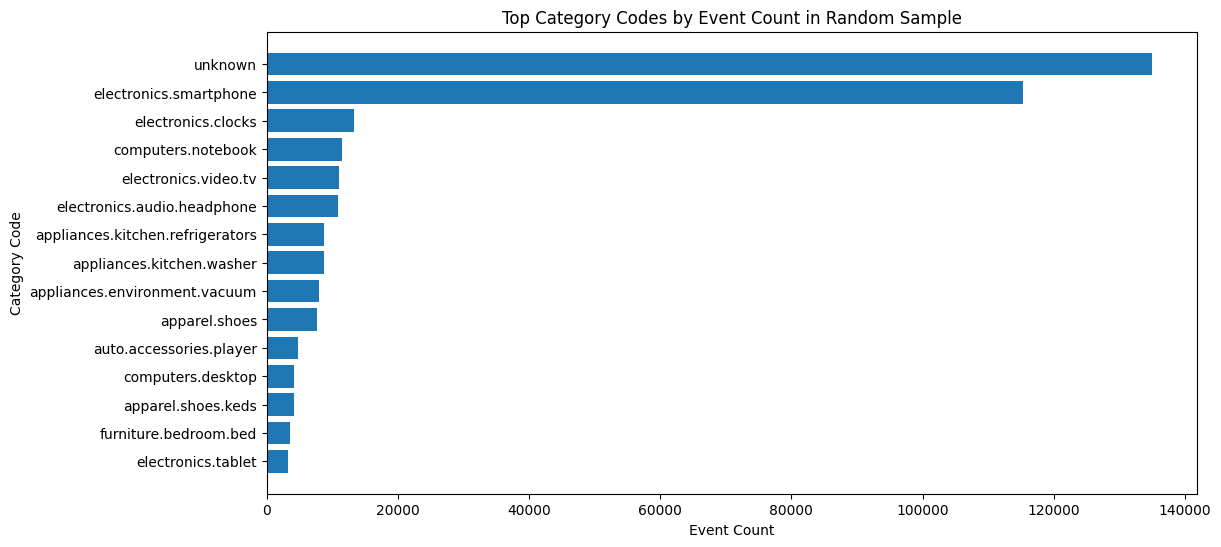

In [26]:
plt.figure(figsize=(12, 6))
plt.barh(top_categories["category_code"], top_categories["event_count"])
plt.title("Top Category Codes by Event Count in Random Sample")
plt.xlabel("Event Count")
plt.ylabel("Category Code")
plt.gca().invert_yaxis()
plt.show()

In [27]:
top_brands = (
    df_sample["brand"]
    .fillna("unknown")
    .value_counts()
    .head(15)
    .reset_index()
)

top_brands.columns = ["brand", "event_count"]
top_brands

,brand,event_count
0,unknown,60896
1,samsung,53011
2,apple,41209
3,xiaomi,30919
4,huawei,11089
5,lucente,6546
6,lg,5632
7,bosch,5535
8,oppo,4734
9,sony,4618


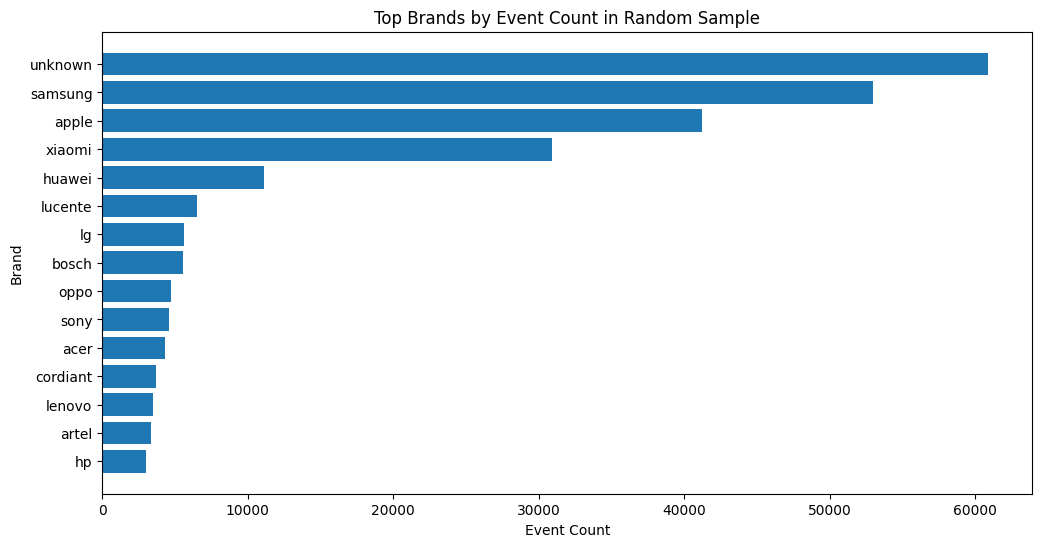

In [28]:
plt.figure(figsize=(12, 6))
plt.barh(top_brands["brand"], top_brands["event_count"])
plt.title("Top Brands by Event Count in Random Sample")
plt.xlabel("Event Count")
plt.ylabel("Brand")
plt.gca().invert_yaxis()
plt.show()

In [29]:
# Price and Revenue Profits :
price_summary = df_sample["price"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame()
price_summary

,price
count,424488.000000
mean,290.674140
std,358.302665
min,0.000000
25%,65.640000
50%,163.050000
75%,358.570000
90%,744.910000
95%,1013.180000
99%,1741.340000


In [30]:
purchase_sample = df_sample[df_sample["event_type"] == "purchase"].copy()

revenue_summary = pd.DataFrame({
    "metric": [
        "purchase_events",
        "purchasing_users",
        "purchasing_sessions",
        "sample_revenue",
        "avg_purchase_value",
        "min_purchase_price",
        "max_purchase_price"
    ],
    "value": [
        len(purchase_sample),
        purchase_sample["user_id"].nunique(),
        purchase_sample["user_session"].nunique(),
        round(purchase_sample["price"].sum(), 2),
        round(purchase_sample["price"].mean(), 2),
        purchase_sample["price"].min(),
        purchase_sample["price"].max()
    ]
})

revenue_summary

,metric,value
0,purchase_events,7373.00
1,purchasing_users,7141.00
2,purchasing_sessions,7359.00
3,sample_revenue,2248703.76
4,avg_purchase_value,304.99
5,min_purchase_price,0.90
6,max_purchase_price,2573.79


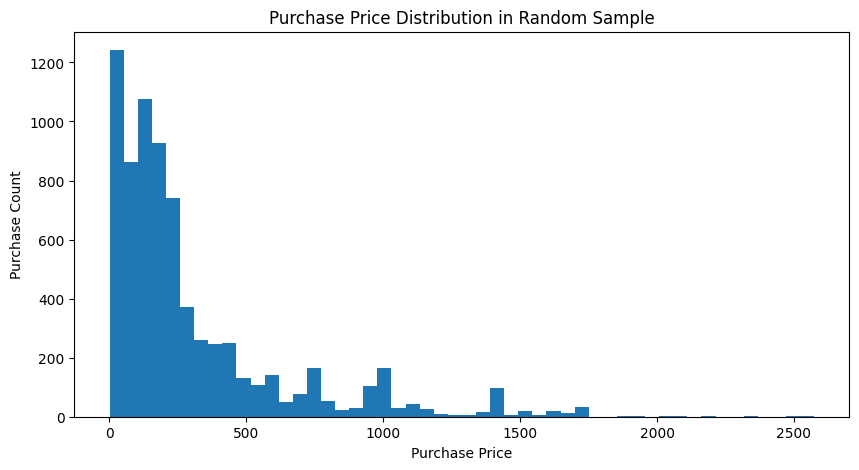

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(purchase_sample["price"], bins=50)
plt.title("Purchase Price Distribution in Random Sample")
plt.xlabel("Purchase Price")
plt.ylabel("Purchase Count")
plt.show()

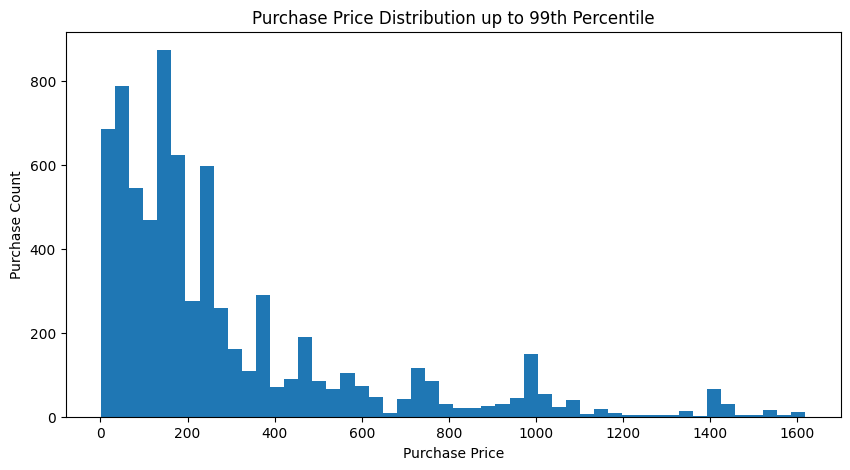

np.float64(1619.09)

In [32]:
purchase_price_p99 = purchase_sample["price"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(purchase_sample[purchase_sample["price"] <= purchase_price_p99]["price"], bins=50)
plt.title("Purchase Price Distribution up to 99th Percentile")
plt.xlabel("Purchase Price")
plt.ylabel("Purchase Count")
plt.show()

purchase_price_p99

In [33]:
# Funnel Baseline Analysis : 
funnel_counts = (
    df_sample["event_type"]
    .value_counts()
    .reindex(["view", "cart", "purchase"])
    .reset_index()
)

funnel_counts.columns = ["funnel_step", "event_count"]

view_count = funnel_counts.loc[funnel_counts["funnel_step"] == "view", "event_count"].iloc[0]
cart_count = funnel_counts.loc[funnel_counts["funnel_step"] == "cart", "event_count"].iloc[0]
purchase_count = funnel_counts.loc[funnel_counts["funnel_step"] == "purchase", "event_count"].iloc[0]

funnel_counts["pct_of_views"] = (funnel_counts["event_count"] / view_count * 100).round(2)

funnel_counts

,funnel_step,event_count,pct_of_views
0,view,407931,100.00
1,cart,9184,2.25
2,purchase,7373,1.81


In [34]:
funnel_conversion_summary = pd.DataFrame({
    "metric": [
        "view_to_cart_rate",
        "cart_to_purchase_rate",
        "view_to_purchase_rate"
    ],
    "value_pct": [
        round(cart_count / view_count * 100, 2),
        round(purchase_count / cart_count * 100, 2),
        round(purchase_count / view_count * 100, 2)
    ]
})

funnel_conversion_summary

,metric,value_pct
0,view_to_cart_rate,2.25
1,cart_to_purchase_rate,80.28
2,view_to_purchase_rate,1.81


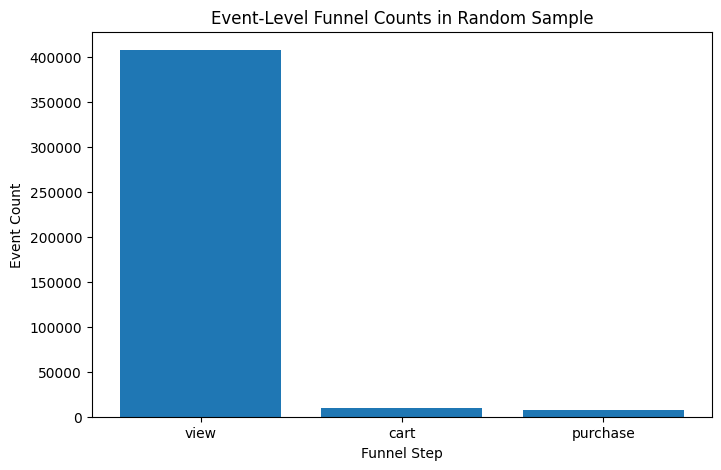

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(funnel_counts["funnel_step"], funnel_counts["event_count"])
plt.title("Event-Level Funnel Counts in Random Sample")
plt.xlabel("Funnel Step")
plt.ylabel("Event Count")
plt.show()

In [36]:
# Session Level Funnel Analytics 
session_funnel = (
    df_sample
    .groupby("user_session")
    .agg(
        user_id=("user_id", "first"),
        session_start=("event_time_parsed", "min"),
        session_end=("event_time_parsed", "max"),
        events_in_session=("event_type", "count"),
        has_view=("event_type", lambda x: int((x == "view").any())),
        has_cart=("event_type", lambda x: int((x == "cart").any())),
        has_purchase=("event_type", lambda x: int((x == "purchase").any())),
    )
    .reset_index()
)

session_funnel.head()

,user_session,user_id,session_start,session_end,events_in_session,has_view,has_cart,has_purchase
0,000097b7-14fd-4336-a0e6-c82c981f8817,557816044,2019-10-17 17:55:38+00:00,2019-10-17 17:55:38+00:00,1,1,0,0
1,0000be48-eb0e-43e6-8b78-25f8bd078926,512845701,2019-10-14 05:52:05+00:00,2019-10-14 05:52:05+00:00,1,1,0,0
2,0000c341-ceab-4141-b196-ba53d4ebf455,562786298,2019-10-26 17:41:30+00:00,2019-10-26 17:41:30+00:00,1,1,0,0
3,0000ceff-df7d-4596-9bf0-8107fa36b27a,515826228,2019-10-08 14:05:24+00:00,2019-10-08 14:05:24+00:00,1,1,0,0
4,0000de39-dc74-414d-8da6-83ad56135bf5,561610048,2019-10-19 11:14:33+00:00,2019-10-19 11:14:33+00:00,1,1,0,0


In [37]:
session_funnel_summary = pd.DataFrame({
    "metric": [
        "total_sessions",
        "sessions_with_view",
        "sessions_with_cart",
        "sessions_with_purchase",
        "avg_events_per_session"
    ],
    "value": [
        len(session_funnel),
        session_funnel["has_view"].sum(),
        session_funnel["has_cart"].sum(),
        session_funnel["has_purchase"].sum(),
        round(session_funnel["events_in_session"].mean(), 2)
    ]
})

session_funnel_summary

,metric,value
0,total_sessions,399070.00
1,sessions_with_view,383718.00
2,sessions_with_cart,9081.00
3,sessions_with_purchase,7359.00
4,avg_events_per_session,1.06


In [38]:
sessions_with_view = session_funnel["has_view"].sum()
sessions_with_cart = session_funnel["has_cart"].sum()
sessions_with_purchase = session_funnel["has_purchase"].sum()

session_conversion_summary = pd.DataFrame({
    "metric": [
        "session_view_to_cart_rate",
        "session_cart_to_purchase_rate",
        "session_view_to_purchase_rate"
    ],
    "value_pct": [
        round(sessions_with_cart / sessions_with_view * 100, 2),
        round(sessions_with_purchase / sessions_with_cart * 100, 2),
        round(sessions_with_purchase / sessions_with_view * 100, 2)
    ]
})

session_conversion_summary

,metric,value_pct
0,session_view_to_cart_rate,2.37
1,session_cart_to_purchase_rate,81.04
2,session_view_to_purchase_rate,1.92


In [39]:
SESSION_SAMPLE_MODULO = 100   # roughly 1% of sessions
CHUNK_SIZE = 500_000

session_sample_chunks = []

for chunk in pd.read_csv(csv_path, chunksize=CHUNK_SIZE):
    session_hash = pd.util.hash_pandas_object(
        chunk["user_session"].astype(str),
        index=False
    )
    
    sampled_chunk = chunk[session_hash % SESSION_SAMPLE_MODULO == 0]
    session_sample_chunks.append(sampled_chunk)

df_session_sample = pd.concat(session_sample_chunks, ignore_index=True)

print("Session-based sample shape:", df_session_sample.shape)
df_session_sample.head()

Session-based sample shape: (425944, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.62,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
1,2019-10-01 00:00:22 UTC,view,1480714,2053013561092866779,computers.desktop,pulser,921.49,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
2,2019-10-01 00:01:33 UTC,view,1480734,2053013561092866779,computers.desktop,pulser,983.27,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
3,2019-10-01 00:01:47 UTC,view,1480456,2053013561092866779,computers.desktop,pulser,1016.73,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
4,2019-10-01 00:02:58 UTC,view,1480456,2053013561092866779,computers.desktop,pulser,1016.73,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9


In [40]:
df_session_sample["event_time_parsed"] = pd.to_datetime(
    df_session_sample["event_time"],
    utc=True,
    errors="coerce"
)

print("Invalid timestamps:", df_session_sample["event_time_parsed"].isna().sum())

Invalid timestamps: 0


In [41]:
session_funnel_clean = (
    df_session_sample
    .groupby("user_session")
    .agg(
        user_id=("user_id", "first"),
        session_start=("event_time_parsed", "min"),
        session_end=("event_time_parsed", "max"),
        events_in_session=("event_type", "count"),
        has_view=("event_type", lambda x: int((x == "view").any())),
        has_cart=("event_type", lambda x: int((x == "cart").any())),
        has_purchase=("event_type", lambda x: int((x == "purchase").any())),
    )
    .reset_index()
)

session_funnel_clean["session_duration_minutes"] = (
    session_funnel_clean["session_end"] - session_funnel_clean["session_start"]
).dt.total_seconds() / 60

session_funnel_clean.head()

,user_session,user_id,session_start,session_end,events_in_session,has_view,has_cart,has_purchase,session_duration_minutes
0,0000ad84-e25c-4c6b-84b2-11502dcd5882,513273141,2019-10-14 03:08:42+00:00,2019-10-14 03:09:44+00:00,2,1,0,0,1.033333
1,0000c56e-d60a-468b-9394-47c8a66fc27b,514527028,2019-10-10 07:36:02+00:00,2019-10-10 07:36:02+00:00,1,1,0,0,0.000000
2,00030e0a-b766-4630-a380-4a7ba1552c13,539244425,2019-10-05 05:13:06+00:00,2019-10-05 05:13:06+00:00,1,1,0,0,0.000000
3,00033d57-3cf1-448d-bbdf-af1e403d9acb,559385462,2019-10-12 06:57:23+00:00,2019-10-12 07:04:56+00:00,15,1,1,1,7.550000
4,00037dc4-3301-4438-8fb1-a5151f37814b,552429214,2019-10-10 09:21:20+00:00,2019-10-10 09:22:06+00:00,4,1,0,0,0.766667


In [42]:
session_funnel_clean_summary = pd.DataFrame({
    "metric": [
        "total_sessions",
        "sessions_with_view",
        "sessions_with_cart",
        "sessions_with_purchase",
        "avg_events_per_session",
        "median_events_per_session",
        "avg_session_duration_minutes",
        "median_session_duration_minutes"
    ],
    "value": [
        len(session_funnel_clean),
        session_funnel_clean["has_view"].sum(),
        session_funnel_clean["has_cart"].sum(),
        session_funnel_clean["has_purchase"].sum(),
        round(session_funnel_clean["events_in_session"].mean(), 2),
        round(session_funnel_clean["events_in_session"].median(), 2),
        round(session_funnel_clean["session_duration_minutes"].mean(), 2),
        round(session_funnel_clean["session_duration_minutes"].median(), 2)
    ]
})

session_funnel_clean_summary

,metric,value
0,total_sessions,92530.00
1,sessions_with_view,92514.00
2,sessions_with_cart,5643.00
3,sessions_with_purchase,6318.00
4,avg_events_per_session,4.60
5,median_events_per_session,2.00
6,avg_session_duration_minutes,17.96
7,median_session_duration_minutes,1.05


In [43]:
sessions_with_view = session_funnel_clean["has_view"].sum()
sessions_with_cart = session_funnel_clean["has_cart"].sum()
sessions_with_purchase = session_funnel_clean["has_purchase"].sum()

session_conversion_clean_summary = pd.DataFrame({
    "metric": [
        "session_view_to_cart_rate",
        "session_cart_to_purchase_rate",
        "session_view_to_purchase_rate"
    ],
    "value_pct": [
        round(sessions_with_cart / sessions_with_view * 100, 2),
        round(sessions_with_purchase / sessions_with_cart * 100, 2),
        round(sessions_with_purchase / sessions_with_view * 100, 2)
    ]
})

session_conversion_clean_summary

,metric,value_pct
0,session_view_to_cart_rate,6.10
1,session_cart_to_purchase_rate,111.96
2,session_view_to_purchase_rate,6.83


In [44]:
def classify_journey(row):
    if row["has_view"] == 1 and row["has_cart"] == 1 and row["has_purchase"] == 1:
        return "view_cart_purchase"
    elif row["has_view"] == 1 and row["has_cart"] == 1 and row["has_purchase"] == 0:
        return "view_cart_no_purchase"
    elif row["has_view"] == 1 and row["has_cart"] == 0 and row["has_purchase"] == 1:
        return "view_purchase_no_cart"
    elif row["has_view"] == 1 and row["has_cart"] == 0 and row["has_purchase"] == 0:
        return "view_only"
    elif row["has_view"] == 0 and row["has_cart"] == 1 and row["has_purchase"] == 1:
        return "cart_purchase_no_view"
    elif row["has_view"] == 0 and row["has_cart"] == 0 and row["has_purchase"] == 1:
        return "purchase_only"
    else:
        return "other"

session_funnel_clean["journey_pattern"] = session_funnel_clean.apply(classify_journey, axis=1)

journey_pattern_summary = (
    session_funnel_clean["journey_pattern"]
    .value_counts()
    .reset_index()
)

journey_pattern_summary.columns = ["journey_pattern", "session_count"]
journey_pattern_summary["session_pct"] = (
    journey_pattern_summary["session_count"] 
    / journey_pattern_summary["session_count"].sum() 
    * 100
).round(2)

journey_pattern_summary

,journey_pattern,session_count,session_pct
0,view_only,83460,90.20
1,view_purchase_no_cart,3421,3.70
2,view_cart_purchase,2887,3.12
3,view_cart_no_purchase,2746,2.97
4,purchase_only,6,0.01
5,other,6,0.01
6,cart_purchase_no_view,4,0.00


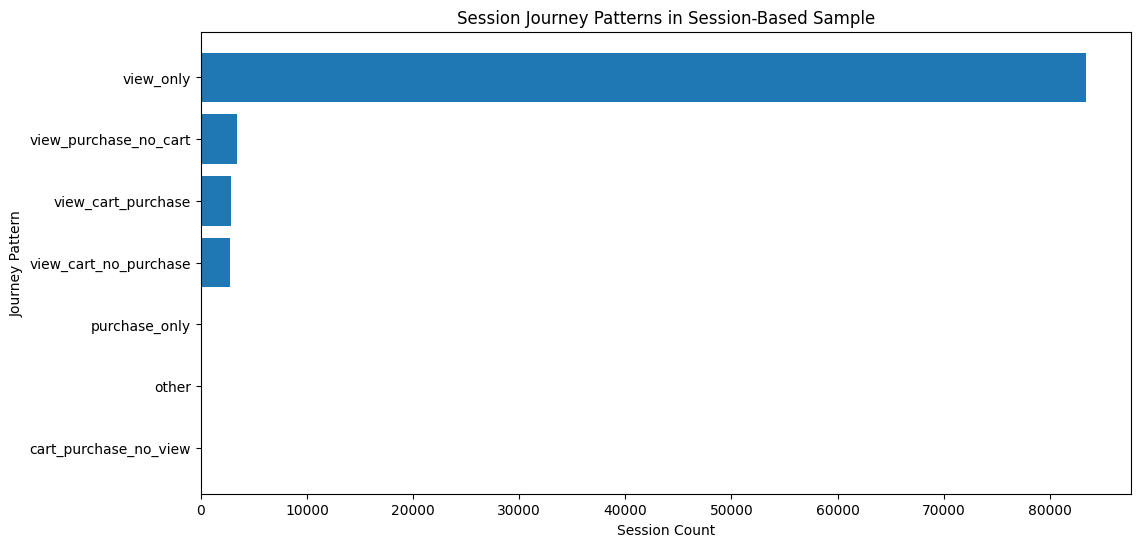

In [45]:
plt.figure(figsize=(12, 6))
plt.barh(journey_pattern_summary["journey_pattern"], journey_pattern_summary["session_count"])
plt.title("Session Journey Patterns in Session-Based Sample")
plt.xlabel("Session Count")
plt.ylabel("Journey Pattern")
plt.gca().invert_yaxis()
plt.show()

In [46]:
transformation_decisions = pd.DataFrame([
    {
        "eda_finding": "event_time is stored as text but parses successfully as UTC timestamp",
        "business_meaning": "Time-based analysis is possible",
        "transformation_decision": "Cast event_time to timestamp and derive event_date, event_hour, day_of_week, and month",
        "dbt_model_impact": "stg_events, dim_date, mart_growth_daily"
    },
    {
        "eda_finding": "category_code has high missingness",
        "business_meaning": "Some product category reporting will fall into an unknown segment",
        "transformation_decision": "Replace null category_code with 'unknown'",
        "dbt_model_impact": "dim_product / product staging"
    },
    {
        "eda_finding": "brand has missing values",
        "business_meaning": "Brand-level attribution is possible but incomplete",
        "transformation_decision": "Replace null brand with 'unknown'",
        "dbt_model_impact": "dim_product / product staging"
    },
    {
        "eda_finding": "view events dominate the dataset",
        "business_meaning": "Most users browse without deeper funnel action",
        "transformation_decision": "Create funnel metrics for view, cart, and purchase events",
        "dbt_model_impact": "fact_funnel_steps, mart_growth_daily"
    },
    {
        "eda_finding": "purchase events are a small share of total events",
        "business_meaning": "Conversion rate is low relative to browsing volume",
        "transformation_decision": "Build conversion fact table from purchase events only",
        "dbt_model_impact": "fact_conversions"
    },
    {
        "eda_finding": "price distribution is right-skewed",
        "business_meaning": "Average revenue can be influenced by high-value purchases",
        "transformation_decision": "Keep price values but monitor percentiles and outliers",
        "dbt_model_impact": "fact_conversions, mart_growth_daily"
    },
    {
        "eda_finding": "session journeys are not always strict view-cart-purchase",
        "business_meaning": "Some users purchase without a tracked cart event",
        "transformation_decision": "Use independent session flags instead of enforcing strict funnel sequence",
        "dbt_model_impact": "fact_sessions, fact_funnel_steps"
    },
    {
        "eda_finding": "sessions have measurable duration and event depth",
        "business_meaning": "Engagement metrics can be calculated",
        "transformation_decision": "Calculate session_start, session_end, session_duration, and events_in_session",
        "dbt_model_impact": "fact_sessions"
    }
])

transformation_decisions

,eda_finding,business_meaning,transformation_decision,dbt_model_impact
0,event_time is stored as text but parses succes...,Time-based analysis is possible,Cast event_time to timestamp and derive event_...,"stg_events, dim_date, mart_growth_daily"
1,category_code has high missingness,Some product category reporting will fall into...,Replace null category_code with 'unknown',dim_product / product staging
2,brand has missing values,Brand-level attribution is possible but incomp...,Replace null brand with 'unknown',dim_product / product staging
3,view events dominate the dataset,Most users browse without deeper funnel action,"Create funnel metrics for view, cart, and purc...","fact_funnel_steps, mart_growth_daily"
4,purchase events are a small share of total events,Conversion rate is low relative to browsing vo...,Build conversion fact table from purchase even...,fact_conversions
5,price distribution is right-skewed,Average revenue can be influenced by high-valu...,Keep price values but monitor percentiles and ...,"fact_conversions, mart_growth_daily"
6,session journeys are not always strict view-ca...,Some users purchase without a tracked cart event,Use independent session flags instead of enfor...,"fact_sessions, fact_funnel_steps"
7,sessions have measurable duration and event depth,Engagement metrics can be calculated,"Calculate session_start, session_end, session_...",fact_sessions


In [47]:
output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

transformation_decisions.to_csv(
    output_dir / "eda_transformation_decisions.csv",
    index=False
)

print("Saved transformation decision matrix.")

Saved transformation decision matrix.
